## **Potato Leaf Disease Detection using Image Classification**

### **Project Description**

This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.

### **Objectives**

● Understand image classification using deep learning

● Perform data preprocessing and augmentation

● Train and evaluate a CNN-based model

#### Load Dataset

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


### Main folder

In [ ]:
import os
print(os.listdir(path))

['PlantVillage', 'PotatoPlants']


In [ ]:
base_path = os.path.join(path,'PotatoPlants')
print(os.listdir(base_path))

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


###Display 5 images of each class

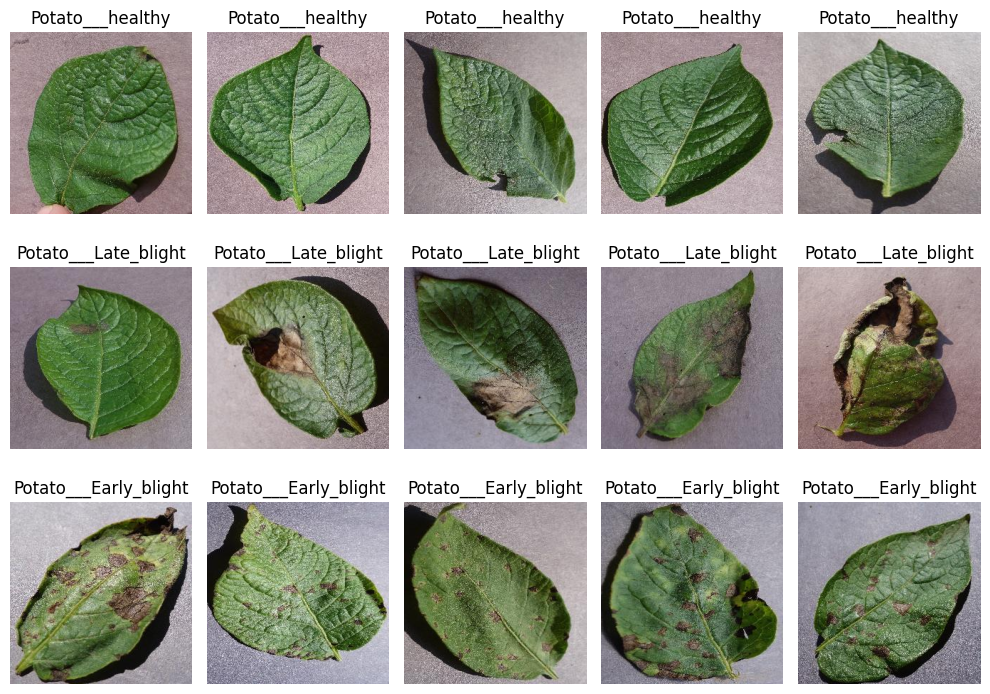

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
# Python image library
base_path = os.path.join(path,'PotatoPlants')
plt.figure(figsize=(10,12))

i = 1
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)
  #print(class_path)

  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      image_path = os.path.join(class_path,img)
      img = Image.open(image_path)

      plt.subplot(5,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')
      i+=1
plt.tight_layout()
plt.show()

In [ ]:
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)
  #print(class_path)

  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,':',count)

Potato___healthy : 152
Potato___Late_blight : 1000
Potato___Early_blight : 1000


### Create dataframe which includes imagepath and labels

In [ ]:
import pandas as pd
data=[]
base_path = os.path.join(path,'PotatoPlants')
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      data.append([img_path,class_name])
df = pd.DataFrame(data,columns=['image_path','label'])

###Shuffle data

In [ ]:
df = df.sample(frac=1,random_state=42).reset_index()

###Split data for training,validation and testing

In [ ]:
train_size = int(0.7* len(df))
test_size = int(0.15* len(df))
val_size = int(0.15* len(df))
print("train_size---->",train_size)
print("test_size---->",test_size)
print("val_size---->",val_size)

train_size----> 1506
test_size----> 322
val_size----> 322


In [ ]:
train_data = df.iloc[:train_size]
# df.loc[:52500]
test_data = df.iloc[train_size:train_size+test_size]
val_data = df.iloc[train_size+test_size :]
print("train_data--->",len(train_data))
print("test_data--->",len(test_data))
print("val_data--->",len(val_data))

train_data---> 1506
test_data---> 322
val_data---> 324


### find size of image

In [ ]:
img = df['image_path'][0]
image = Image.open(img)
height,width = image.size
print(height,width)

256 256


## Data preprocessing

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#ImageDataGenerator used for data cleaning
batch_size = 32
img_height = 224
img_width = 224

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, # Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 1506 validated image filenames belonging to 3 classes.


In [ ]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 322 validated image filenames belonging to 3 classes.


In [ ]:
# val data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 324 validated image filenames belonging to 3 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 48)
Train Label Shape: (32, 3)

Validation Shape: (32, 224, 224, 3) (Batches = 11)
Validation Label Shape: (32, 3)

Test Shape: (32, 224, 224, 3) (Batches = 11)
Test Label Shape: (32, 3)



## Model building

In [ ]:
from tensorflow.keras import models,layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
n_classes=3
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation = 'softmax')
])

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,331 (2.61 MB)

 Trainable params: 683,331 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer=Adam(),loss=categorical_crossentropy,
                  metrics=['accuracy'])

###Model Training

In [ ]:
cnn = cnn_model.fit(
    train_generator,epochs= 3 ,
    validation_data = val_generator,verbose=1
)

Epoch 1/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.6089 - loss: 0.8391 - val_accuracy: 0.7284 - val_loss: 0.6518
Epoch 2/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.7550 - loss: 0.6159 - val_accuracy: 0.8580 - val_loss: 0.4191
Epoch 3/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.8327 - loss: 0.4148 - val_accuracy: 0.8611 - val_loss: 0.3108


### Model Evaluation

In [ ]:
# Evaluate on the training data
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8161 - loss: 0.4071
Training accuracy: 0.8161
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8199 - loss: 0.4099
Test accuracy: 0.8199


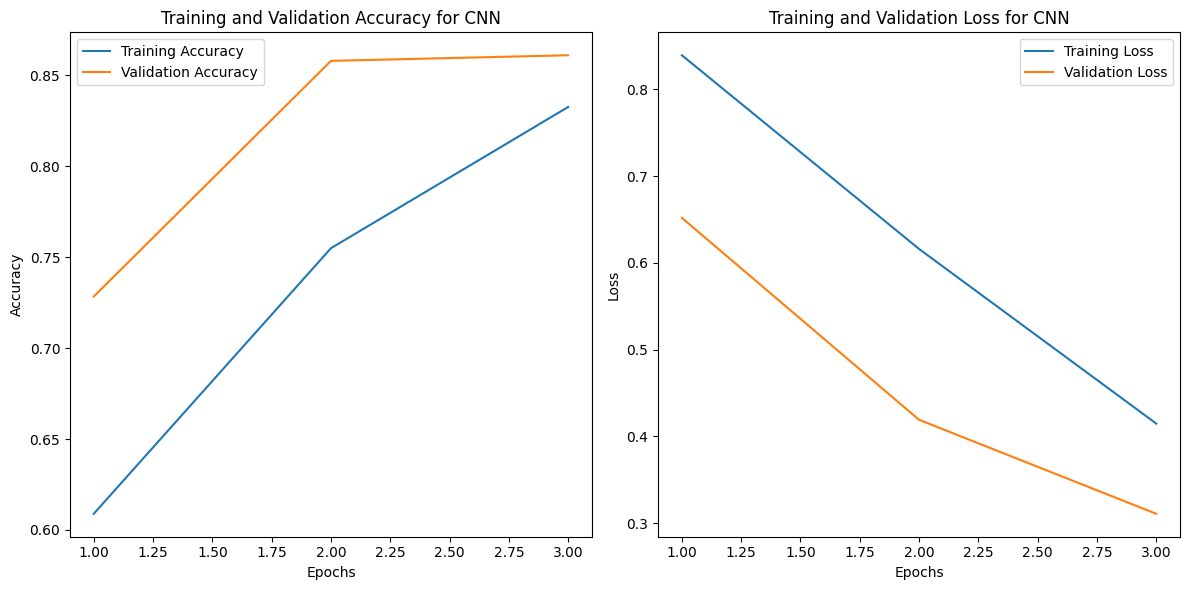

In [ ]:
# Retrieve metrics from the training history
acc = cnn.history['accuracy']
val_acc = cnn.history['val_accuracy']
loss = cnn.history['loss']
val_loss = cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Confusion Matrix

import numpy as np
from sklearn.metrics import confusion_matrix

# Reset generator
test_generator.reset()

# Predictions
pred = cnn_model.predict(test_generator)

# Convert probabilities → class index
pred_classes = np.argmax(pred, axis=1)

# True labels
true_classes = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

print("Confusion Matrix:")
print(cm)

11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Confusion Matrix:
[[79 61  0]
 [83 77  1]
 [13  8  0]]


In [ ]:
# Classification Report

from sklearn.metrics import classification_report

# Class labels
class_labels = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.45      0.56      0.50       140
 Potato___Late_blight       0.53      0.48      0.50       161
     Potato___healthy       0.00      0.00      0.00        21

             accuracy                           0.48       322
            macro avg       0.33      0.35      0.33       322
         weighted avg       0.46      0.48      0.47       322

